In [1]:
#1.Imports
# numpy: operaciones numéricas eficientes (arrays, logaritmos, medias, etc.)
import numpy as np

# pandas: manipulación de datos tabulares (DataFrames)
import pandas as pd

# GEOparse: descarga y lectura de datasets del repositorio GEO
# nos permite acceder directamente a datasets de expresión génica
import GEOparse

# matplotlib: generación de gráficos
import matplotlib.pyplot as plt

# Pipeline: permite encadenar pasos (preprocesado + modelo)
# clave para evitar data leakage dentro de validación cruzada
from sklearn.pipeline import Pipeline

# StandardScaler: normaliza variables (media=0, var=1)
# necesario para modelos sensibles a escala (SVM, regresión)
from sklearn.preprocessing import StandardScaler

# VarianceThreshold: elimina variables con poca variabilidad
# útil para quitar genes irrelevantes
# SelectKBest: selecciona las K mejores variables según un criterio
# f_classif: ANOVA, mide relación entre variable y clase
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# StratifiedKFold: validación cruzada manteniendo proporción de clases
# cross_validate: ejecuta CV y devuelve métricas
from sklearn.model_selection import StratifiedKFold, cross_validate

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression  # modelo lineal interpretable
from sklearn.svm import SVC                           # SVM (potente en alta dimensión)
from sklearn.ensemble import RandomForestClassifier   # modelo robusto basado en árboles

import time
import winsound  # solo Windows

In [2]:
#2. CONFIGURACIÓN

# Fijamos semilla para reproducibilidad
# esto asegura que los resultados sean replicables
RANDOM_STATE = 42

# Número de variables (genes) que se seleccionarán
# hiperparámetro importante que controla complejidad del modelo
K_VALUES = [20, 50, 100, 500, 1000]

In [16]:
#3. Dataset
# Descargamos el dataset GSE55348 desde GEO
# si ya está descargado, se reutiliza (no descarga otra vez)
gse = GEOparse.get_GEO("GSE55348", destdir="../data")

30-Mar-2026 13:44:44 DEBUG utils - Directory ../data already exists. Skipping.
30-Mar-2026 13:44:44 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE55nnn/GSE55348/soft/GSE55348_family.soft.gz to ../data\GSE55348_family.soft.gz
100%|█████████████████████████████████████████████████████████████████████████████| 25.1M/25.1M [00:17<00:00, 1.53MB/s]
30-Mar-2026 13:45:02 DEBUG downloader - Size validation passed
30-Mar-2026 13:45:02 DEBUG downloader - Moving C:\Users\PEDROV~1\AppData\Local\Temp\tmpiwrj9thd to C:\Users\Pedro Valenzuela\data\GSE55348_family.soft.gz
30-Mar-2026 13:45:02 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE55nnn/GSE55348/soft/GSE55348_family.soft.gz
30-Mar-2026 13:45:02 INFO GEOparse - Parsing ../data\GSE55348_family.soft.gz: 
30-Mar-2026 13:45:02 DEBUG GEOparse - DATABASE: GeoMiame
30-Mar-2026 13:45:02 DEBUG GEOparse - SERIES: GSE55348
30-Mar-2026 13:45:02 DEBUG GEOparse - PLATFORM: GPL14951
30-Mar-2026 13:45:

In [17]:
#4. Matriz de Expresión (X)
# Creamos un diccionario donde:
# clave = muestra (paciente)
# valor = vector de expresión génica
expr_data = {}

# Iteramos sobre todas las muestras del dataset
for gsm_name, gsm in gse.gsms.items():
    
    # gsm.table contiene los datos del microarray
    # ID_REF = identificador del gen/probe
    # VALUE = nivel de expresión
    
    # Convertimos la tabla en un vector indexado por genes
    expr_data[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

# Convertimos el diccionario en DataFrame
# filas = muestras, columnas = genes
X = pd.DataFrame(expr_data).T

print("Shape X:", X.shape)

# Ver metadata de varias muestras
for gsm_name, gsm in list(gse.gsms.items())[:5]:
    print("Sample:", gsm_name)
    for key, value in gsm.metadata.items():
        print(key, ":", value)
    print("------\n")

print("NaNs en X:", X.isna().sum().sum())

print(X.dtypes.unique())

Shape X: (53, 29377)
Sample: GSM1334487
title : ['BA11']
geo_accession : ['GSM1334487']
status : ['Public on Oct 19 2015']
submission_date : ['Feb 25 2014']
last_update_date : ['Oct 19 2015']
type : ['RNA']
channel_count : ['1']
source_name_ch1 : ['formalin-fixed paraffin-embedded tissue']
organism_ch1 : ['Homo sapiens']
taxid_ch1 : ['9606']
characteristics_ch1 : ['age: 67', 't: T1', 'n: pos', 'grade: III', 'er: neg', 'pgr: neg', 'her2: pos', 'event: 1', 'time to relapse: 500']
molecule_ch1 : ['total RNA']
extract_protocol_ch1 : ['RNA was extracted with Trizol reagent, followed by clean-up and DNase I treatment with QIAGEN RNeasy mini kit in accordance with the prescribed protocol provided with the kit. Quality control was performed with Agilent Bioanalyser.']
label_ch1 : ['biotin']
label_protocol_ch1 : ['Biotinylated cRNA were prepared with the Ambion MessageAmp kit for Illumina arrays']
hyb_protocol : ['Standard Illumina hybridization protocol']
scan_protocol : ['Standard Illumina sc

In [18]:
#5. EXTRACCIÓN DE LABELS (ADAPTADO A GSE55348)

# Lista donde guardaremos la variable objetivo (evento: recaída/metástasis sí/no)
y = []

# Iteramos sobre cada muestra
for gsm_name, gsm in gse.gsms.items():
    
    # Obtenemos metadatos clínicos
    chars = gsm.metadata.get("characteristics_ch1", [])
    
    label = None
    
    # Buscamos el campo relevante dentro de los metadatos
    for c in chars:
        c = c.lower()
        
        # 🔄 CAMBIO CLAVE:
        # En GSE58984 usábamos "distant metastasis"
        # En GSE55348 la variable viene como:
        # "event: 0" o "event: 1"
        
        if "event:" in c:
            
            # Extraemos el valor numérico (0 = no evento, 1 = evento)
            label = int(c.split(":")[-1].strip())
    
    # Control de errores:
    # si no encontramos etiqueta para una muestra, algo está mal
    if label is None:
        raise ValueError(f"No se pudo extraer label para {gsm_name}")
    
    y.append(label)

# Convertimos a array numpy (formato esperado por sklearn)
y = np.array(y)

# Comprobamos distribución de clases
print("Distribución de clases:", np.bincount(y))

# Verificación de que hay exactamente dos clases (problema binario)
assert len(np.unique(y)) == 2, "Error: solo hay una clase"

Distribución de clases: [30 23]


In [19]:
#6. Transformación Logaritmica
# Aplicamos log2(x + 1)
# motivo:
# - los datos de microarray son altamente asimétricos
# - el log estabiliza la varianza y mejora modelos
X_log = np.log2(X + 1)

In [20]:
# 7. PIPELINES Y EVALUACIÓN
# Lista donde guardaremos los resultados de todos los experimentos
results = []

# Validación cruzada estratificada (mantiene proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Iteramos sobre los distintos valores de K (nº de features)
for K in K_VALUES:

    # Definimos pipelines para este valor de K
    pipelines = {

        # --------------------------------------------------
        # BASELINE (sin selección de variables)
        # --------------------------------------------------
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),  # elimina genes con baja varianza
            ("scaler", StandardScaler()),                     # normaliza datos
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # LOGISTIC REGRESSION + ANOVA
        # --------------------------------------------------
        f"LR + SelectKBest (K={K})": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),  # selecciona K genes más relevantes
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # SVM (RBF) + SELECCIÓN
        # --------------------------------------------------
        f"SVM (RBF) + SelectKBest (K={K})": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # RANDOM FOREST + SELECCIÓN
        # --------------------------------------------------
        f"RF + SelectKBest (K={K})": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE
            ))
        ])
    }

    # ============================================================
    # EVALUACIÓN
    # ============================================================
    for name, pipe in pipelines.items():

        # Ejecutamos CV y obtenemos accuracy en cada fold
        scores = cross_validate(
            pipe,
            X_log,
            y,
            cv=cv,
            scoring="accuracy",
            n_jobs=2,                # paralelización controlada
            pre_dispatch="2*n_jobs"
        )

        # Guardamos resultados agregados
        results.append({
            "model": name,
            "K": K,
            "mean_accuracy": scores["test_score"].mean(),
            "std_accuracy": scores["test_score"].std()
        })

# ============================================================
# RESULTADOS
# ============================================================

# Convertimos resultados a DataFrame
results_df = pd.DataFrame(results)

# Mostramos resultados
print(results_df)

                               model     K  mean_accuracy  std_accuracy
0                        LR baseline    20       0.696364      0.162582
1            LR + SelectKBest (K=20)    20       0.829091      0.144817
2     SVM (RBF) + SelectKBest (K=20)    20       0.792727      0.142979
3            RF + SelectKBest (K=20)    20       0.865455      0.137318
4                        LR baseline    50       0.696364      0.162582
5            LR + SelectKBest (K=50)    50       0.756364      0.131413
6     SVM (RBF) + SelectKBest (K=50)    50       0.774545      0.132416
7            RF + SelectKBest (K=50)    50       0.829091      0.132914
8                        LR baseline   100       0.696364      0.162582
9           LR + SelectKBest (K=100)   100       0.678182      0.163191
10   SVM (RBF) + SelectKBest (K=100)   100       0.734545      0.194673
11          RF + SelectKBest (K=100)   100       0.772727      0.162623
12                       LR baseline   500       0.696364      0

In [21]:
# 8. VALIDACIÓN CRUZADA (EXPERIMENTO CON DISTINTOS K)

import time
from sklearn.feature_selection import mutual_info_classif, RFE

# Guardamos tiempo total del experimento
total_start = time.time()

# Validación cruzada estratificada (mantiene proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Lista donde guardaremos TODOS los resultados
all_results = []

# Loop sobre distintos valores de K (número de genes seleccionados)
for K in K_VALUES:

    print(f"\nEvaluando K = {K}")

    # ============================================================
    # PIPELINES (dependen de K)
    # ============================================================
    pipelines = {

        # --------------------------------------------------
        # BASELINE (sin selección de variables)
        # --------------------------------------------------
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # ANOVA
        # --------------------------------------------------
        "LR + ANOVA": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # MUTUAL INFORMATION
        # --------------------------------------------------
        "LR + MutualInfo": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(
                score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE),
                k=K
            )),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # RFE
        # --------------------------------------------------
        "LR + RFE": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", RFE(
                estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_features_to_select=K,
                step=50
            )),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ])
    }

    # ============================================================
    # EVALUACIÓN
    # ============================================================
    for name, pipe in pipelines.items():

        # Evitar RFE muy grande
        if name == "LR + RFE" and K > 1000:
            continue

        print(f"K={K} | Modelo: {name}")

        start = time.time()

        scores = cross_validate(
            pipe,
            X_log,
            y,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "f1": "f1",
                "accuracy": "accuracy"
            },
            return_train_score=False,
            n_jobs=3,
            pre_dispatch="2*n_jobs"
        )

        end = time.time()
        print(f"Tiempo: {end - start:.2f} s")

        all_results.append({
            "Model": name,
            "K": K,
            "ROC-AUC": np.mean(scores["test_roc_auc"]),
            "F1": np.mean(scores["test_f1"]),
            "Accuracy": np.mean(scores["test_accuracy"])
        })

# ============================================================
# FIN BLOQUE 8
# ============================================================

total_end = time.time()
print(f"\nTiempo total: {total_end - total_start:.2f} s")

print("\n=== FIN EXPERIMENTO K ===")


Evaluando K = 20
K=20 | Modelo: LR baseline
Tiempo: 2.75 s
K=20 | Modelo: LR + ANOVA
Tiempo: 1.15 s
K=20 | Modelo: LR + MutualInfo
Tiempo: 63.35 s
K=20 | Modelo: LR + RFE
Tiempo: 72.81 s

Evaluando K = 50
K=50 | Modelo: LR baseline
Tiempo: 1.43 s
K=50 | Modelo: LR + ANOVA
Tiempo: 1.20 s
K=50 | Modelo: LR + MutualInfo
Tiempo: 61.10 s
K=50 | Modelo: LR + RFE
Tiempo: 68.86 s

Evaluando K = 100
K=100 | Modelo: LR baseline
Tiempo: 1.41 s
K=100 | Modelo: LR + ANOVA
Tiempo: 1.19 s
K=100 | Modelo: LR + MutualInfo
Tiempo: 60.96 s
K=100 | Modelo: LR + RFE
Tiempo: 69.99 s

Evaluando K = 500
K=500 | Modelo: LR baseline
Tiempo: 1.42 s
K=500 | Modelo: LR + ANOVA
Tiempo: 1.42 s
K=500 | Modelo: LR + MutualInfo
Tiempo: 63.19 s
K=500 | Modelo: LR + RFE
Tiempo: 73.94 s

Evaluando K = 1000
K=1000 | Modelo: LR baseline
Tiempo: 1.39 s
K=1000 | Modelo: LR + ANOVA
Tiempo: 1.21 s
K=1000 | Modelo: LR + MutualInfo
Tiempo: 62.70 s
K=1000 | Modelo: LR + RFE
Tiempo: 73.31 s

Tiempo total: 684.79 s

=== FIN EXPERIM

In [22]:
# ============================================================
# 9. EXPERIMENTO L1 (SPARSIDAD)
# ============================================================

print("\n=== EXPERIMENTO L1 ===")

# Valores de regularización
C_VALUES = [0.01, 0.1, 1]

l1_results = []

for C in C_VALUES:

    print(f"\nEvaluando L1 con C = {C}")

    pipe = Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            C=C,
            random_state=RANDOM_STATE
        ))
    ])

    start = time.time()

    scores = cross_validate(
        pipe,
        X_log,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "accuracy": "accuracy"
        },
        return_train_score=False,
        n_jobs=2,
        pre_dispatch="2*n_jobs"
    )

    end = time.time()
    print(f"Tiempo: {end - start:.2f} s")

    l1_results.append({
        "Model": "LR L1",
        "C": C,
        "ROC-AUC": np.mean(scores["test_roc_auc"]),
        "F1": np.mean(scores["test_f1"]),
        "Accuracy": np.mean(scores["test_accuracy"])
    })

# Convertimos a DataFrame
l1_df = pd.DataFrame(l1_results)

print("\n=== RESULTADOS L1 ===")
print(l1_df)


=== EXPERIMENTO L1 ===

Evaluando L1 con C = 0.01
Tiempo: 2.96 s

Evaluando L1 con C = 0.1
Tiempo: 134.57 s

Evaluando L1 con C = 1
Tiempo: 163.08 s

=== RESULTADOS L1 ===
   Model     C   ROC-AUC        F1  Accuracy
0  LR L1  0.01  0.500000  0.000000  0.567273
1  LR L1  0.10  0.958333  0.837778  0.869091
2  LR L1  1.00  0.820000  0.731111  0.732727


In [23]:
#Bloque 9 Alternativo-No lineal Random Forest
# ============================================================
# 1. RANDOM FOREST (MODELO NO LINEAL)
# ============================================================

import time  # sirve para medir cuánto tarda cada parte del código
from sklearn.ensemble import RandomForestClassifier  # modelo de árboles (no lineal)

print("\n=== EXPERIMENTO RANDOM FOREST ===")

rf_results = []  # lista donde guardaremos los resultados del modelo

total_start = time.time()  # inicio del tiempo total del bloque

# Validación cruzada estratificada:
# divide los datos en 5 partes manteniendo proporción de clases
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Definimos el pipeline (flujo de trabajo del modelo)
rf_model = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),  # elimina variables casi constantes
    ("model", RandomForestClassifier(
        n_estimators=200,        # número de árboles en el bosque
        max_depth=None,          # profundidad ilimitada (árboles complejos)
        random_state=RANDOM_STATE,
        n_jobs=2                 # usa 2 cores para entrenar árboles en paralelo
    ))
])

print("Entrenando Random Forest...")

start = time.time()  # inicio del tiempo del modelo

# cross_validate:
# entrena y evalúa el modelo en distintos splits de los datos
scores = cross_validate(
    rf_model,
    X_log,   # datos (genes)
    y,       # etiquetas (metástasis sí/no)
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",   # métrica principal (capacidad de discriminación)
        "f1": "f1",             # equilibrio entre precisión y recall
        "accuracy": "accuracy"  # porcentaje de aciertos
    },
    return_train_score=False,  # no guardamos métricas de entrenamiento
    n_jobs=1   # importante: evitamos paralelización doble (RF ya usa cores)
)

end = time.time()
print(f"Tiempo RF: {end - start:.2f} s")  # tiempo que ha tardado el modelo

# Guardamos los resultados promediados de los folds
rf_results.append({
    "Model": "Random Forest",
    "K": "N/A",  # no usamos selección de variables aquí
    "ROC-AUC": np.mean(scores["test_roc_auc"]),
    "F1": np.mean(scores["test_f1"]),
    "Accuracy": np.mean(scores["test_accuracy"])
})

rf_df = pd.DataFrame(rf_results)  # convertimos a tabla

print("\nResultados Random Forest:")
print(rf_df)


# ============================================================
# 2. SVM (LINEAL Y NO LINEAL)
# ============================================================

from sklearn.svm import SVC  # modelo de máquinas de soporte vectorial

print("\n=== EXPERIMENTO SVM ===")

svm_results = []  # lista de resultados

# ============================================================
# SVM LINEAL
# ============================================================

print("\nEntrenando SVM Linear...")

start = time.time()

# Pipeline para SVM lineal
svm_linear = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),  # filtrado inicial
    ("scaler", StandardScaler()),  # normaliza datos (muy importante para SVM)
    ("model", SVC(
        kernel="linear",  # frontera de decisión lineal
        probability=True, # necesario para calcular ROC-AUC
        random_state=RANDOM_STATE
    ))
])

scores = cross_validate(
    svm_linear,
    X_log,
    y,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "f1": "f1",
        "accuracy": "accuracy"
    },
    n_jobs=2  # paralelizamos folds
)

end = time.time()
print(f"Tiempo SVM Linear: {end - start:.2f} s")

# Guardamos resultados
svm_results.append({
    "Model": "SVM Linear",
    "K": "N/A",
    "C": None,
    "Type": "SVM",
    "ROC-AUC": np.mean(scores["test_roc_auc"]),
    "F1": np.mean(scores["test_f1"]),
    "Accuracy": np.mean(scores["test_accuracy"])
})


# ============================================================
# SVM RBF (NO LINEAL)
# ============================================================

print("\nEntrenando SVM RBF...")

start = time.time()

# Pipeline para SVM no lineal
svm_rbf = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),  # necesario para que SVM funcione bien
    ("model", SVC(
        kernel="rbf",  # kernel radial → permite relaciones no lineales
        probability=True,
        random_state=RANDOM_STATE
    ))
])

scores = cross_validate(
    svm_rbf,
    X_log,
    y,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "f1": "f1",
        "accuracy": "accuracy"
    },
    n_jobs=2
)

end = time.time()
print(f"Tiempo SVM RBF: {end - start:.2f} s")

# Guardamos resultados
svm_results.append({
    "Model": "SVM RBF",
    "K": "N/A",
    "C": None,
    "Type": "SVM",
    "ROC-AUC": np.mean(scores["test_roc_auc"]),
    "F1": np.mean(scores["test_f1"]),
    "Accuracy": np.mean(scores["test_accuracy"])
})


# ============================================================
# RESULTADOS SVM
# ============================================================

svm_df = pd.DataFrame(svm_results)  # convertimos a DataFrame
svm_df["Type"] = "SVM"
svm_df["C"] = np.nan
svm_df["K"] = "N/A"

# Orden de columnas consistente con el resto
svm_df = svm_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]

print("\n=== RESULTADOS SVM ===")
print(svm_df)


# ============================================================
# FIN BLOQUE
# ============================================================

total_end = time.time()
print(f"\nTiempo total bloque no lineal: {total_end - total_start:.2f} s")

# Sonido al terminar (solo Windows)
import winsound
winsound.Beep(1000, 500)

print("\n=== FIN EXPERIMENTO NO LINEAL ===")


=== EXPERIMENTO RANDOM FOREST ===
Entrenando Random Forest...
Tiempo RF: 3.77 s

Resultados Random Forest:
           Model    K  ROC-AUC        F1  Accuracy
0  Random Forest  N/A   0.8175  0.499567  0.641818

=== EXPERIMENTO SVM ===

Entrenando SVM Linear...
Tiempo SVM Linear: 1.81 s

Entrenando SVM RBF...
Tiempo SVM RBF: 1.94 s

=== RESULTADOS SVM ===
        Model    K   C Type   ROC-AUC        F1  Accuracy
0  SVM Linear  N/A NaN  SVM  0.776667  0.677778  0.696364
1     SVM RBF  N/A NaN  SVM  0.736667  0.372727  0.583636

Tiempo total bloque no lineal: 7.53 s

=== FIN EXPERIMENTO NO LINEAL ===


In [54]:
# 10. RESULTADOS (EXPERIMENTO K)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("ROC-AUC", ascending=False)

print("\n=== RESULTADOS EXPERIMENTO K ===")
print(results_df)


# ============================================================
# 10.1. RESULTADOS L1
# ============================================================

l1_df = pd.DataFrame(l1_results)
l1_df = l1_df.sort_values("ROC-AUC", ascending=False)

print("\n=== RESULTADOS L1 ===")
print(l1_df)


# ============================================================
# 10.2. RESULTADOS RANDOM FOREST
# ============================================================

rf_df["Type"] = "RF"
rf_df["C"] = np.nan
rf_df["K"] = "N/A"

rf_df = rf_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]

print("\n=== RESULTADOS RANDOM FOREST ===")
print(rf_df)


# ============================================================
# RESULTADOS UNIFICADOS (K + L1 + RF)
# ============================================================

# Añadimos tipo a K
results_df["Type"] = "K-based"
results_df["C"] = np.nan

# Añadimos tipo a L1
l1_df["Type"] = "L1"
l1_df["K"] = "auto"

# Orden de columnas consistente
results_df = results_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]
l1_df = l1_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]

# Concatenamos todo
combined_df = pd.concat([results_df, l1_df, rf_df, svm_df], ignore_index=True)

# Ordenamos por rendimiento
combined_df = combined_df.sort_values("ROC-AUC", ascending=False)

print("\nTipos de modelos en combined_df:")
print(combined_df["Type"].value_counts())




=== RESULTADOS EXPERIMENTO K ===
              Model     K   ROC-AUC        F1  Accuracy
2   LR + MutualInfo    20  0.903333  0.727778  0.754545
1        LR + ANOVA    20  0.896667  0.822222  0.829091
5        LR + ANOVA    50  0.860000  0.733333  0.756364
6   LR + MutualInfo    50  0.855000  0.694488  0.734545
9        LR + ANOVA   100  0.831667  0.644444  0.678182
3          LR + RFE    20  0.830000  0.633377  0.696364
10  LR + MutualInfo   100  0.825000  0.696869  0.734545
11         LR + RFE   100  0.810000  0.593333  0.640000
7          LR + RFE    50  0.810000  0.593333  0.640000
14  LR + MutualInfo   500  0.805000  0.666667  0.698182
17       LR + ANOVA  1000  0.798333  0.644444  0.678182
19         LR + RFE  1000  0.796667  0.677778  0.696364
15         LR + RFE   500  0.791667  0.653535  0.698182
12      LR baseline   500  0.790000  0.677778  0.696364
8       LR baseline   100  0.790000  0.677778  0.696364
16      LR baseline  1000  0.790000  0.677778  0.696364
4       LR bas

In [ ]:
# 11. GUARDADO


import os

os.makedirs("../results", exist_ok=True)

# Guardamos por separado (más limpio)
results_df.to_csv("../results/results_k_based.csv", index=False)
l1_df.to_csv("../results/results_l1.csv", index=False)

# Guardamos combinado (muy útil)
combined_df.to_csv("../results/results_combined.csv", index=False)

print("Resultados guardados correctamente")

In [ ]:
# 12. VISUALIZACIÓN COMPLETA (TODOS LOS MODELOS)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# ------------------------------------------------------------
# 1. IMPACTO DE K (SOLO MODELOS K-based)
# ------------------------------------------------------------
# Filtramos solo modelos que usan K
df_k = combined_df[combined_df["Type"] == "K-based"]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_k,
    x="K",
    y="ROC-AUC",
    hue="Model",
    marker="o"
)

plt.title("Impacto del número de genes (K)")
plt.xlabel("Número de genes")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. IMPACTO DE L1 (REGULARIZACIÓN)
# ------------------------------------------------------------
# Filtramos solo L1
df_l1 = combined_df[combined_df["Type"] == "L1"]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_l1,
    x="C",
    y="ROC-AUC",
    marker="o"
)

plt.xscale("log")

plt.title("Impacto de L1 (regularización)")
plt.xlabel("C")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN GLOBAL (TODOS LOS MODELOS)
# ------------------------------------------------------------
# ESTE ES EL GRÁFICO CLAVE

plt.figure(figsize=(12, 6))

plot_df = combined_df.sort_values("ROC-AUC", ascending=False)

sns.barplot(
    data=plot_df,
    x="ROC-AUC",
    y="Model",
    hue="Type"
)

plt.title("Comparación global de modelos")
plt.xlabel("ROC-AUC")
plt.ylabel("Modelo")

plt.legend(title="Tipo")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. TOP MODELOS (más limpio)
# ------------------------------------------------------------

top_models = combined_df.sort_values("ROC-AUC", ascending=False).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_models,
    x="ROC-AUC",
    y="Model",
    hue="Type"
)

plt.title("Top 10 modelos")
plt.xlabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. COMPARACIÓN POR TIPO DE MODELO
# ------------------------------------------------------------
# Para ver diferencias entre enfoques

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_df,
    x="Type",
    y="ROC-AUC"
)

plt.title("Distribución de rendimiento por tipo de modelo")
plt.xlabel("Tipo de modelo")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FIN BLOQUE
# ------------------------------------------------------------
print("\n=== FIN VISUALIZACIÓN COMPLETA ===")

# 13. ANÁLISIS DE ESTABILIDAD DE GENES (CORREGIDO)
# Ahora mapeamos correctamente los índices a genes reales

from collections import Counter
import numpy as np

print("\n=== ANÁLISIS DE ESTABILIDAD DE GENES ===")

TOP_K_GENES = 50
selected_genes_all_folds = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_log, y)):

    print(f"\nFold {fold+1}")

    X_train, X_test = X_log.iloc[train_idx], X_log.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe = Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

    pipe.fit(X_train, y_train)

    # ============================================================
    # EXTRAER COEFICIENTES
    # ============================================================
    coefs = pipe.named_steps["model"].coef_[0]
    abs_coefs = np.abs(coefs)

    # ============================================================
    # MAPEO CORRECTO DE GENES
    # ============================================================

    # Máscara de genes que sobreviven al VarianceThreshold
    mask = pipe.named_steps["variance"].get_support()

    # Nombres originales de genes
    original_genes = X_train.columns

    # Genes después del filtrado
    genes_after_variance = original_genes[mask]

    # ============================================================
    # SELECCIÓN DE TOP GENES
    # ============================================================
    top_indices = np.argsort(abs_coefs)[-TOP_K_GENES:]

    # ⚠️ AQUÍ ESTÁ EL CAMBIO IMPORTANTE
    top_genes = genes_after_variance[top_indices]

    selected_genes_all_folds.extend(top_genes)

    print(f"Top {TOP_K_GENES} genes extraídos")


# ============================================================
# FRECUENCIA DE GENES
# ============================================================

gene_counts = Counter(selected_genes_all_folds)

gene_freq = sorted(gene_counts.items(), key=lambda x: x[1], reverse=True)

print("\n=== GENES MÁS FRECUENTES ===")

for gene, count in gene_freq[:20]:
    print(f"{gene} aparece en {count} folds")


# ============================================================
# EXTRA (MUY ÚTIL)
# ============================================================

print("\nNúmero total de genes únicos seleccionados:", len(gene_counts))

In [132]:
# ============================================================
# 14. EXTRACCIÓN DE GENES DEL MODELO L1 FINAL
# ============================================================

print("\n=== EXTRACCIÓN DE GENES L1 ===")

l1_pipe = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

l1_pipe.fit(X_log, y)

coefs = l1_pipe.named_steps["model"].coef_[0]

mask = l1_pipe.named_steps["variance"].get_support()
genes_after_variance = X_log.columns[mask]

selected_mask = coefs != 0
selected_genes = genes_after_variance[selected_mask]
selected_coefs = coefs[selected_mask]

abs_coefs = np.abs(selected_coefs)
sorted_idx = np.argsort(abs_coefs)[::-1]

top_genes = selected_genes[sorted_idx]
top_coefs = selected_coefs[sorted_idx]

print(f"\nNúmero de genes seleccionados: {len(top_genes)}")

genes_df = pd.DataFrame({
    "Gene": top_genes,
    "Coefficient": top_coefs
})

genes_df.to_csv("../results/l1_selected_genes.csv", index=False)

print("Genes guardados")


=== EXTRACCIÓN DE GENES L1 ===

Número de genes seleccionados: 11
Genes guardados


In [133]:
# ============================================================
# 15. CARGAR GENES SELECCIONADOS
# ============================================================

genes_df = pd.read_csv("../results/l1_selected_genes.csv")

selected_genes = genes_df["Gene"].values

print("Número de genes cargados:", len(selected_genes))

Número de genes cargados: 11


In [134]:
# ============================================================
# 16. MAPEO GSE55348 (CORREGIDO)
# ============================================================

print("\n=== MAPEO GSE55348 ===")

platform_55348 = gse.gpls[list(gse.gpls.keys())[0]]
annot_55348 = platform_55348.table

mapping_55348 = annot_55348[['ID', 'Symbol']].dropna()

map_55348 = dict(zip(mapping_55348['ID'], mapping_55348['Symbol']))

print("Mapping creado:", len(map_55348))

# ============================================================
# 16B. MAPEAR GENES L1 A SYMBOL (SIN DUPLICADOS)
# ============================================================

print("\n=== MAPEO GENES L1 ===")

mapped_selected_genes = [map_55348.get(g) for g in selected_genes]

# eliminar None + eliminar duplicados manteniendo orden
mapped_selected_genes = list(dict.fromkeys(
    [g for g in mapped_selected_genes if g is not None]
))

print("Genes originales:", len(selected_genes))
print("Genes mapeados únicos:", len(mapped_selected_genes))
print(mapped_selected_genes)


=== MAPEO GSE55348 ===
Mapping creado: 29377

=== MAPEO GENES L1 ===
Genes originales: 11
Genes mapeados únicos: 8
['GRB7', 'C1QTNF7', 'ERBB2', 'C1orf186', 'PGAP3', 'C17orf37', 'VPS37B', 'FXR1']


In [135]:
# ============================================================
# 17. CARGAR GSE58984
# ============================================================

print("\n=== CARGANDO GSE58984 ===")

gse_58984 = GEOparse.get_GEO("GSE58984", destdir="../data")

expr_data_58984 = {}

for gsm_name, gsm in gse_58984.gsms.items():
    expr_data_58984[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

X_58984 = pd.DataFrame(expr_data_58984).T

print("Shape:", X_58984.shape)

30-Mar-2026 15:45:01 DEBUG utils - Directory ../data already exists. Skipping.
30-Mar-2026 15:45:01 INFO GEOparse - File already exist: using local version.
30-Mar-2026 15:45:01 INFO GEOparse - Parsing ../data\GSE58984_family.soft.gz: 
30-Mar-2026 15:45:01 DEBUG GEOparse - DATABASE: GeoMiame
30-Mar-2026 15:45:01 DEBUG GEOparse - SERIES: GSE58984
30-Mar-2026 15:45:01 DEBUG GEOparse - PLATFORM: GPL570



=== CARGANDO GSE58984 ===


C:\Users\Pedro Valenzuela\AppData\Roaming\Python\Python312\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
30-Mar-2026 15:45:02 DEBUG GEOparse - SAMPLE: GSM1423346
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423347
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423348
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423349
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423350
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423351
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423352
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423353
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423354
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423355
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423356
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423357
30-Mar-2026 15:45:03 DEBUG GEOparse - SAMPLE: GSM1423358


Shape: (94, 54675)


In [155]:
# ============================================================
# 18. LOG TRANSFORM
# ============================================================

X_58984_log = np.log2(X_58984 + 1)

In [156]:
# ============================================================
# 19. extraigo LABELS
# ============================================================
y_58984 = []

for gsm_name in X_58984.index:
    gsm = gse_58984.gsms[gsm_name]

    chars = gsm.metadata.get("characteristics_ch1", [])
    label = None

    for c in chars:
        c_low = c.lower()

        # formato: "distant metastasis: 0/1"
        if "distant metastasis" in c_low:
            label = int(c_low.split(":")[-1].strip())

    if label is None:
        raise ValueError(f"No label en {gsm_name}")

    y_58984.append(label)

y_58984 = np.array(y_58984)

print("Distribución clases:", np.bincount(y_58984))
print("Shape y:", y_58984.shape)

Distribución clases: [83 11]
Shape y: (94,)


In [157]:
# ============================================================
# 20.MAPEO GSE58984 (PROBE → GENE SYMBOL)
# ============================================================

print("\n=== MAPEO GSE58984 ===")

platform_58984 = gse_58984.gpls[list(gse_58984.gpls.keys())[0]]
annot_58984 = platform_58984.table

print("Columnas:")
print(annot_58984.columns)

mapping_58984 = annot_58984[['ID', 'Gene Symbol']].dropna()
map_58984 = dict(zip(mapping_58984['ID'], mapping_58984['Gene Symbol']))

print("Mapping creado:", len(map_58984))


=== MAPEO GSE58984 ===
Columnas:
Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')
Mapping creado: 45782


In [158]:
# ============================================================
# 21. CHECK GENES L1 EN GSE58984
# ============================================================

print("\n=== CHECK GENES L1 EN GSE58984 ===")

genes_l1 = mapped_selected_genes

present_genes = [g for g in genes_l1 if g in X_58984_genes.columns]
missing_genes = [g for g in genes_l1 if g not in X_58984_genes.columns]

# eliminar duplicados también aquí (por seguridad)
present_genes = list(dict.fromkeys(present_genes))

print("Genes originales:", genes_l1)
print("\nGenes presentes:", len(present_genes))
print(present_genes)

print("\nGenes ausentes:", len(missing_genes))
print(missing_genes)


=== CHECK GENES L1 EN GSE58984 ===
Genes originales: ['GRB7', 'C1QTNF7', 'ERBB2', 'C1orf186', 'PGAP3', 'C17orf37', 'VPS37B', 'FXR1']

Genes presentes: 6
['GRB7', 'C1QTNF7', 'ERBB2', 'PGAP3', 'VPS37B', 'FXR1']

Genes ausentes: 2
['C1orf186', 'C17orf37']


In [159]:
# ============================================================
# 22. DEFINIR GENES COMUNES (TRAIN vs TEST)
# ============================================================

print("\n=== GENES COMUNES ===")

common_genes = [g for g in present_genes if g in X_55348_genes.columns]

# eliminar duplicados (definitivo)
common_genes = list(dict.fromkeys(common_genes))

print("Número de genes comunes:", len(common_genes))
print(common_genes)


=== GENES COMUNES ===
Número de genes comunes: 6
['GRB7', 'C1QTNF7', 'ERBB2', 'PGAP3', 'VPS37B', 'FXR1']


In [160]:
# ============================================================
# 23. MODELO FINAL (TRAIN = GSE58984)
# ============================================================

print("\n=== MODELO FINAL (TRAIN = GSE58984) ===")

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

X_train = X_58984_genes[common_genes]
y_train = y_58984

print("Shape train:", X_train.shape)

final_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")


=== MODELO FINAL (TRAIN = GSE58984) ===
Shape train: (94, 6)
Modelo entrenado correctamente


In [161]:
# 24. MAPEO GSE55348 (PROBE → GENE SYMBOL)
print("\n=== MAPEO GSE55348 ===")

platform_55348 = gse.gpls[list(gse.gpls.keys())[0]]
annot_55348 = platform_55348.table

mapping_55348 = annot_55348[['ID', 'Symbol']].dropna()
map_55348 = dict(zip(mapping_55348['ID'], mapping_55348['Symbol']))

print("Mapping creado:", len(map_55348))


=== MAPEO GSE55348 ===
Mapping creado: 29377


In [162]:
# 25. APLICAR MAPEO A GSE55348
X_55348_genes = X_log.copy()

X_55348_genes.columns = X_55348_genes.columns.map(map_55348)
X_55348_genes = X_55348_genes.loc[:, X_55348_genes.columns.notna()]

X_55348_genes = X_55348_genes.T.groupby(level=0).mean().T

print("Shape tras mapping:", X_55348_genes.shape)


Shape tras mapping: (53, 20819)


In [163]:
# ============================================================
# 27. VALIDACIÓN EXTERNA
# ============================================================

print("\n=== VALIDACIÓN EXTERNA ===")

X_test = X_55348_genes[common_genes]
y_test = y

print("Shape test:", X_test.shape)

y_pred = final_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred)

print("AUC externo:", auc)


=== VALIDACIÓN EXTERNA ===
Shape test: (53, 6)
AUC externo: 0.3760869565217391


In [164]:
print("common_genes:", common_genes)
print("n genes:", len(common_genes))
print("n únicos:", len(set(common_genes)))

common_genes: ['GRB7', 'C1QTNF7', 'ERBB2', 'PGAP3', 'VPS37B', 'FXR1']
n genes: 6
n únicos: 6


In [165]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred)
auc_invertido = roc_auc_score(y_test, 1 - y_pred)

print("AUC:", auc)
print("AUC invertido:", auc_invertido)

AUC: 0.3760869565217391
AUC invertido: 0.6239130434782609



=== CURVA ROC EXTERNA ===


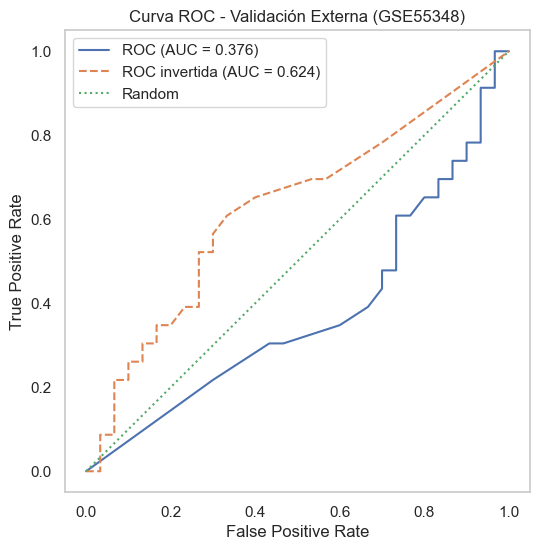

In [166]:
# ============================================================
# 28. CURVA ROC - VALIDACIÓN EXTERNA
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("\n=== CURVA ROC EXTERNA ===")

# Probabilidades del modelo
y_pred = final_model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

# ROC invertida (diagnóstico)
fpr_inv, tpr_inv, _ = roc_curve(y_test, 1 - y_pred)
auc_inv = roc_auc_score(y_test, 1 - y_pred)

# Plot
plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot(fpr_inv, tpr_inv, linestyle="--", label=f"ROC invertida (AUC = {auc_inv:.3f})")

# línea azar
plt.plot([0, 1], [0, 1], linestyle=":", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación Externa (GSE55348)")
plt.legend()
plt.grid()

plt.show()